In [2]:
import pandas as pd 

#use given directory since the csv is too big for github
merged = pd.read_csv("/Users/gianellarobles/Downloads/sample_2013/merged_mortgage_2013.csv")

#all columns for the dataset
merged.columns

/var/folders/63/h0zgkssd48bbn8s4xmhg8hs40000gn/T/ipykernel_10764/3220488591.py:4: DtypeWarning: Columns (3,7,23,24,28,56,57,58,59) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv("/Users/gianellarobles/Downloads/sample_2013/merged_mortgage_2013.csv")


Index(['loan_sequence_number', 'monthly_reporting_period',
       'current_actual_upb', 'current_loan_delinquency_status', 'loan_age',
       'remaining_months_to_legal_maturity', 'defect_settlement_date',
       'modification_flag', 'zero_balance_code', 'zero_balance_effective_date',
       'current_interest_rate', 'current_deferred_upb',
       'due_date_of_last_paid_installment', 'mi_recoveries',
       'net_sales_proceeds', 'non_mi_recoveries', 'expenses', 'legal_costs',
       'maintenance_and_preservation_costs', 'taxes_and_insurance',
       'miscellaneous_expenses', 'actual_loss_calculation',
       'modification_cost', 'step_modification_flag', 'deferred_payment_plan',
       'estimated_loan_to_value', 'zero_balance_removal_upb',
       'delinquent_accrued_interest', 'delinquency_due_to_disaster',
       'borrower_assistance_status_code', 'current_month_modification_cost',
       'interest_bearing_upb', 'credit_score', 'first_payment_date',
       'first_time_homebuyer_flag', 

In [3]:
#count missing values
missing_count = merged.isnull().sum()

#percentage missing
missing_percent = (merged.isnull().sum() / len(merged)) * 100

#combine into one table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
})

#sort from most missing to least
missing_summary = missing_summary.sort_values(
    by="Missing Percent",
    ascending=False
)

#high missing count only
display(missing_summary[missing_summary["Missing Count"] > 0])

,Missing Count,Missing Percent
defect_settlement_date,4132380,99.997871
legal_costs,4132170,99.992789
mi_recoveries,4132170,99.992789
miscellaneous_expenses,4132170,99.992789
taxes_and_insurance,4132170,99.992789
maintenance_and_preservation_costs,4132170,99.992789
expenses,4132170,99.992789
non_mi_recoveries,4132170,99.992789
delinquent_accrued_interest,4132169,99.992765
net_sales_proceeds,4132169,99.992765


In [4]:
#columns that can be dropped 

drop_columns = [
    "defect_settlement_date",
    "legal_costs",
    "mi_recoveries",
    "miscellaneous_expenses",
    "taxes_and_insurance",
    "maintenance_and_preservation_costs",
    "expenses",
    "non_mi_recoveries",
    "delinquent_accrued_interest",
    "net_sales_proceeds",
    "actual_loss_calculation",
    "modification_cost",
    "current_month_modification_cost", 
    "harp_indicator",
    "pre_harp_loan_sequence_number",
    "super_conforming_flag"
]

merged.drop(columns=drop_columns, inplace=True)

print(merged.columns)

Index(['loan_sequence_number', 'monthly_reporting_period',
       'current_actual_upb', 'current_loan_delinquency_status', 'loan_age',
       'remaining_months_to_legal_maturity', 'modification_flag',
       'zero_balance_code', 'zero_balance_effective_date',
       'current_interest_rate', 'current_deferred_upb',
       'due_date_of_last_paid_installment', 'step_modification_flag',
       'deferred_payment_plan', 'estimated_loan_to_value',
       'zero_balance_removal_upb', 'delinquency_due_to_disaster',
       'borrower_assistance_status_code', 'interest_bearing_upb',
       'credit_score', 'first_payment_date', 'first_time_homebuyer_flag',
       'maturity_date', 'metropolitan_statistical_area',
       'mortgage_insurance_percentage', 'number_of_units', 'occupancy_status',
       'original_combined_loan_to_value', 'original_debt_to_income_ratio',
       'original_unpaid_principal_balance', 'original_loan_to_value',
       'original_interest_rate', 'channel', 'prepayment_penalty_mort

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#sample loans for testing - 5000 loans
np.random.seed(42)

unique_loan = merged["loan_sequence_number"].dropna().unique()

sample_size = min(5000, len(unique_loan))

selected_loans = np.random.choice(
    unique_loan,
    size=sample_size,
    replace=False
)

rf_data = merged[
    merged["loan_sequence_number"].isin(selected_loans)
].copy()

rf_data = rf_data.sort_values(
    by=["loan_sequence_number", "monthly_reporting_period"]
)

print("Row: ", len(rf_data))
print("Unique loans: ", rf_data["loan_sequence_number"].nunique())



Row:  412897
Unique loans:  5000


In [6]:
#convert to binary status 0 or 1
    #1=90+ days delinquent 
    #0=current or fewer than 90 days delinquent
def changeDelinquency(status):
   if pd.isna(status):
      return np.nan
   status = str(status).strip().upper()

   if status == "XX":
      return np.nan
   if status == "R":
      return 1

   try: 
      return 1 if int(float(status)) >= 3 else 0
   except (ValueError, TypeError):
      return np.nan

In [7]:
#current month status
rf_data["changeDelinquency"] = (
    rf_data["current_loan_delinquency_status"]
    .apply(changeDelinquency)
)

In [8]:
rf_data["next_month_serious_delinquency"] = (
    rf_data.groupby("loan_sequence_number")["changeDelinquency"]
    .shift(-1)
)

In [9]:
#check next month code for serious delinquency

rf_data[
    [
        "loan_sequence_number",
        "monthly_reporting_period",
        "changeDelinquency",
        "next_month_serious_delinquency"
    ]
].head(10)

#check rows where target changes/becomes delinquent

rf_data.loc[
    rf_data["next_month_serious_delinquency"] == 1,
    [
        "loan_sequence_number",
        "monthly_reporting_period",
        "changeDelinquency",
        "next_month_serious_delinquency"
    ]
].head(10)



,loan_sequence_number,monthly_reporting_period,changeDelinquency,next_month_serious_delinquency
82022,F13Q10042609,201604,0.0,1.0
82023,F13Q10042609,201605,1.0,1.0
82024,F13Q10042609,201606,1.0,1.0
82025,F13Q10042609,201607,1.0,1.0
82026,F13Q10042609,201608,1.0,1.0
96241,F13Q10050308,201306,0.0,1.0
96242,F13Q10050308,201307,1.0,1.0
108392,F13Q10057449,201809,0.0,1.0
108393,F13Q10057449,201810,1.0,1.0
108394,F13Q10057449,201811,1.0,1.0


In [10]:
rf_data.groupby("loan_sequence_number").tail(1)[
    [
        "loan_sequence_number",
        "monthly_reporting_period",
        "next_month_serious_delinquency"
    ]
].head()

,loan_sequence_number,monthly_reporting_period,next_month_serious_delinquency
361,F13Q10000257,201605,NaN
4719,F13Q10002672,201507,NaN
5934,F13Q10003672,202507,NaN
6613,F13Q10004621,201908,NaN
9980,F13Q10006146,201512,NaN


In [11]:
#removing the last month record
rf_data = rf_data.dropna(
    subset=["next_month_serious_delinquency"]
).copy()

#convert target from float to integer
rf_data["next_month_serious_delinquency"] = (
    rf_data["next_month_serious_delinquency"].astype(int)
)

print("Rows remaining: ", rf_data.shape[0])

print("\nTarget counts: ")
print(
    rf_data["next_month_serious_delinquency"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentages: ")
print(
    rf_data["next_month_serious_delinquency"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(4)
)

Rows remaining:  407712

Target counts: 
next_month_serious_delinquency
0    405867
1      1845
Name: count, dtype: int64

Target percentages: 
next_month_serious_delinquency
0    99.5475
1     0.4525
Name: proportion, dtype: float64


In [12]:
#choosing the model columns to input
features = [
    "current_actual_upb",
    "current_interest_rate",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "current_deferred_upb",
    "interest_bearing_upb",
    "credit_score",
    "mortgage_insurance_percentage",
    "number_of_units",
    "original_combined_loan_to_value",
    "original_debt_to_income_ratio",
    "original_unpaid_principal_balance",
    "original_loan_to_value",
    "original_interest_rate",
    "original_loan_term",
    "number_of_borrowers",
    "estimated_loan_to_value"
]

target = "next_month_serious_delinquency"

print("Number of features: ", len(features))

Number of features:  17


In [13]:
#look for missing columns 
missing_columns = [
    column
    for column in features
    if column not in rf_data.columns
]

print("Missing columns: ", missing_columns)
#confirmed empty

Missing columns:  []


In [14]:
#convert features to numeric
for column in features: 
    rf_data[column] = pd.to_numeric(
        rf_data[column],
        errors="coerce"
    )

print(rf_data[features].dtypes)
#all numeric now

current_actual_upb                    float64
current_interest_rate                 float64
loan_age                                int64
remaining_months_to_legal_maturity      int64
current_deferred_upb                  float64
interest_bearing_upb                  float64
credit_score                            int64
mortgage_insurance_percentage           int64
number_of_units                         int64
original_combined_loan_to_value         int64
original_debt_to_income_ratio           int64
original_unpaid_principal_balance       int64
original_loan_to_value                  int64
original_interest_rate                float64
original_loan_term                      int64
number_of_borrowers                     int64
estimated_loan_to_value               float64
dtype: object


In [15]:
#create model dataset
model_data = rf_data[
    ["loan_sequence_number"] + features + [target]
].copy()

print("Model data shape: ", model_data.shape)

model_data.head()

Model data shape:  (407712, 19)


,loan_sequence_number,current_actual_upb,current_interest_rate,loan_age,remaining_months_to_legal_maturity,current_deferred_upb,interest_bearing_upb,credit_score,mortgage_insurance_percentage,number_of_units,original_combined_loan_to_value,original_debt_to_income_ratio,original_unpaid_principal_balance,original_loan_to_value,original_interest_rate,original_loan_term,number_of_borrowers,estimated_loan_to_value,next_month_serious_delinquency
323,F13Q10000257,150000.0,2.75,0,180,0.0,150000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0
324,F13Q10000257,149000.0,2.75,1,179,0.0,149000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0
325,F13Q10000257,149000.0,2.75,2,178,0.0,149000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0
326,F13Q10000257,148000.0,2.75,3,177,0.0,148000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0
327,F13Q10000257,147000.0,2.75,4,176,0.0,147000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0


In [16]:
#creating X, y, and loan groups
X = model_data[features]
y = model_data[target]
groups = model_data["loan_sequence_number"]

print("X shape: ", X.shape)
print("y shape: ", y.shape)
print("Unique loans: ", groups.nunique())


X shape:  (407712, 17)
y shape:  (407712,)
Unique loans:  4997


In [17]:
#split data by loan
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    splitter.split(
        X, 
        y,
        groups=groups
    )
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

train_loans = groups.iloc[train_index]
test_loans = groups.iloc[test_index]

print("X train: ", X_train.shape)
print("X test: ", X_test.shape)
print("y train: ", y_train.shape)
print("y test: ", y_test.shape)

X train:  (324890, 17)
X test:  (82822, 17)
y train:  (324890,)
y test:  (82822,)


In [18]:
#look for overlapping loans
overlapping_loans = set(
    train_loans.unique()
).intersection(
    set(test_loans.unique())
)

print("Training loans: ", train_loans.nunique())
print("Testing loans: ", test_loans.nunique())
print("Overlapping loans: ", len(overlapping_loans))
#confirmed no overlap

Training loans:  3997
Testing loans:  1000
Overlapping loans:  0


In [19]:
training_medians = X_train.median()

X_train = X_train.fillna(training_medians)
X_test = X_test.fillna(training_medians)

#if column is missing and has no median
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Missing values in X train: ", X_train.isnull().sum().sum())
print("Missing values in X test: ", X_test.isnull().sum().sum())


Missing values in X train:  0
Missing values in X test:  0


In [20]:
#class imbalance

print("Training target counts: ", y_train.value_counts().sort_index())

print("\nTraining target percentages: ", y_train.value_counts(normalize=True).sort_index().mul(100).round(4))

print("\nTesting target counts: ", y_test.value_counts().sort_index())

Training target counts:  next_month_serious_delinquency
0    323433
1      1457
Name: count, dtype: int64

Training target percentages:  next_month_serious_delinquency
0    99.5515
1     0.4485
Name: proportion, dtype: float64

Testing target counts:  next_month_serious_delinquency
0    82434
1      388
Name: count, dtype: int64


In [21]:
from sklearn.ensemble import RandomForestClassifier

#Train Random Forest Tree Model
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Training Random Forest: \n")
random_forest.fit(
    X_train, 
    y_train
)

print("\nTraining completed")

Training Random Forest: 



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   17.7s



Training completed


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   19.1s finished


In [22]:
#create predictions
rf_predictions = random_forest.predict(X_test)

rf_probabilities = random_forest.predict_proba(X_test)[:, 1]

print("Predictions created")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Predictions created


[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.2s finished


In [23]:
#calculate evaluation metrics
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)
rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)
rf_recall=recall_score(
    y_test,
    rf_predictions, 
    zero_division=0
)
rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)
rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-score: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_auc:.4f}")

Accuracy: 0.9865
Precision: 0.0054
Recall: 0.0103
F1-score: 0.0071
ROC-AUC: 0.7771


In [24]:
#Classification report
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Not Seriously Delinquent",
            "Seriously Delinquent"
        ],
        zero_division=0
    )
)

Random Forest Classification Report:

                          precision    recall  f1-score   support

Not Seriously Delinquent       1.00      0.99      0.99     82434
    Seriously Delinquent       0.01      0.01      0.01       388

                accuracy                           0.99     82822
               macro avg       0.50      0.50      0.50     82822
            weighted avg       0.99      0.99      0.99     82822



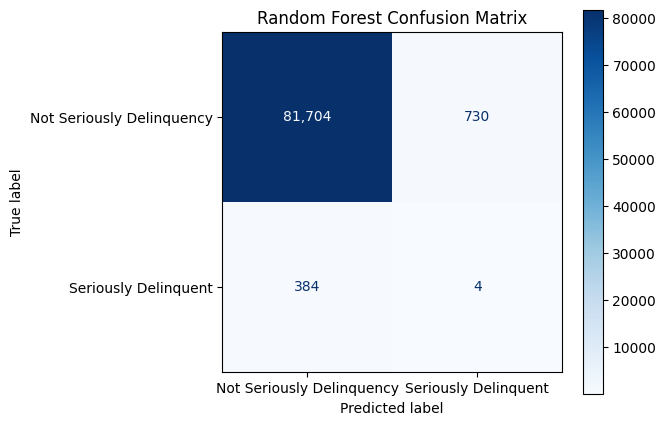

In [25]:
#confusion matrix
rf_confusion_matrix = confusion_matrix(
    y_test,
    rf_predictions
)

matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=rf_confusion_matrix,
    display_labels=[
        "Not Seriously Delinquency",
        "Seriously Delinquent"
    ]
)
matrix_display.plot(values_format=",d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

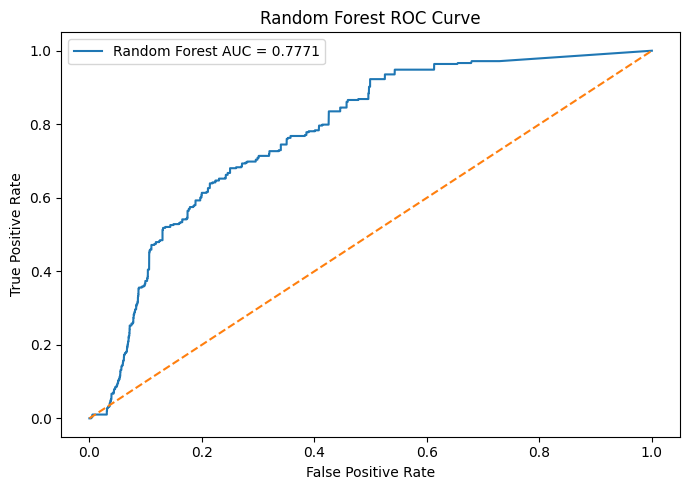

In [26]:
from sklearn.metrics import roc_curve

#ROC curve
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Random Forest AUC = {rf_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
#important features
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,credit_score,0.171314
1,loan_age,0.093475
2,remaining_months_to_legal_maturity,0.082515
3,estimated_loan_to_value,0.077181
4,original_debt_to_income_ratio,0.074345
5,current_interest_rate,0.068775
6,current_actual_upb,0.064260
7,interest_bearing_upb,0.062737
8,original_combined_loan_to_value,0.062720
9,original_loan_to_value,0.060976


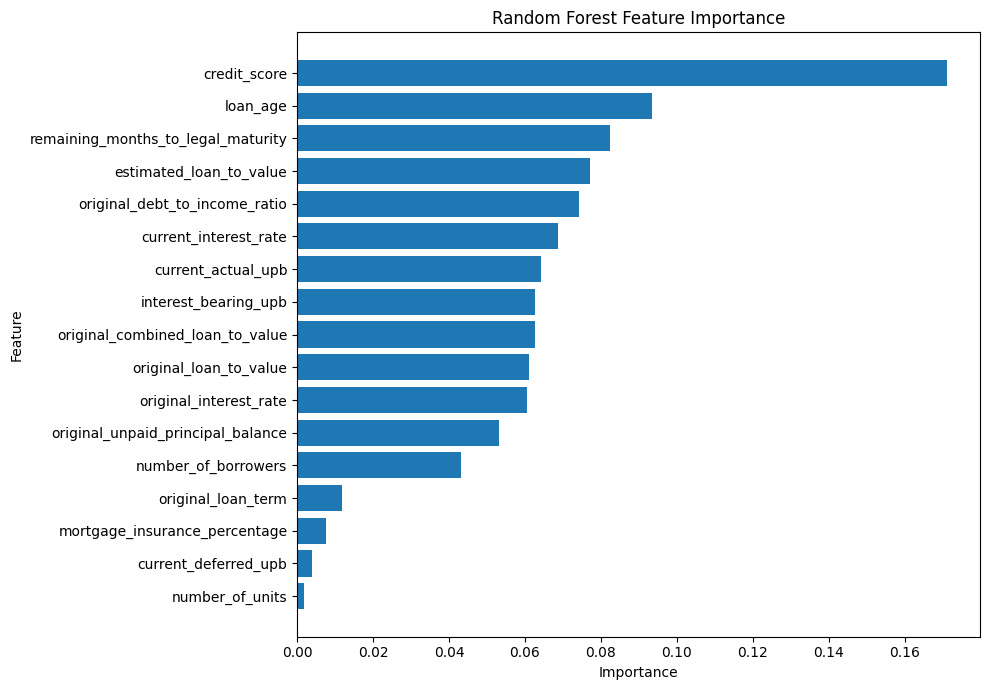

In [28]:
#feature importance graph
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [29]:
#needs improvements - lower classification 
rf_predictions = random_forest.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished


In [30]:
threshold = 0.1

rf_predictions_adjusted = (
    rf_probabilities >= threshold
).astype(int)

In [31]:
print(f"Threshold: {threshold}")

print(
    classification_report(
        y_test,
        rf_predictions_adjusted,
        target_names=[
            "Not Seriously Delinquent",
            "Seriously Delinquent"
        ],
        zero_division=0
    )
)

Threshold: 0.1
                          precision    recall  f1-score   support

Not Seriously Delinquent       1.00      0.89      0.94     82434
    Seriously Delinquent       0.02      0.47      0.04       388

                accuracy                           0.88     82822
               macro avg       0.51      0.68      0.49     82822
            weighted avg       0.99      0.88      0.93     82822



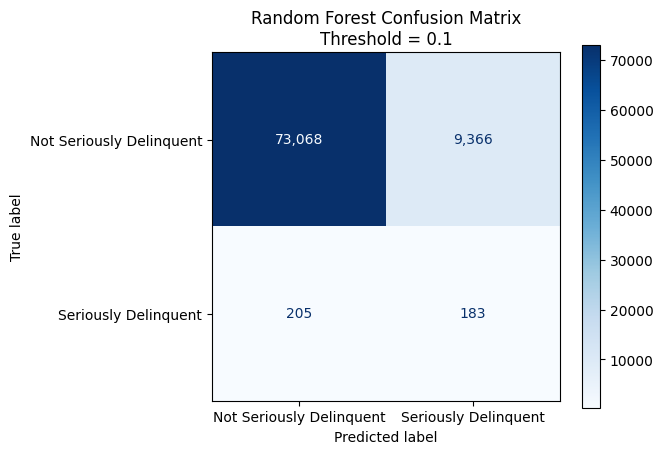

In [32]:
adjusted_cm = confusion_matrix(
    y_test,
    rf_predictions_adjusted
)

adjusted_display = ConfusionMatrixDisplay(
    confusion_matrix=adjusted_cm,
    display_labels=[
        "Not Seriously Delinquent",
        "Seriously Delinquent"
    ]
)

adjusted_display.plot(
    values_format=",d",
    cmap="Blues"
)

plt.title(
    f"Random Forest Confusion Matrix\nThreshold = {threshold}"
)

plt.tight_layout()
plt.show()

In [33]:
for threshold in [0.50, 0.30, 0.20, 0.10, 0.05]:
    predictions = (
        rf_probabilities >= threshold
    ).astype(int)

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision: {precision_score(y_test, predictions, zero_division=0):.4f} | "
        f"Recall: {recall_score(y_test, predictions, zero_division=0):.4f} | "
        f"F1: {f1_score(y_test, predictions, zero_division=0):.4f}"
    )

Threshold 0.50 | Precision: 0.0054 | Recall: 0.0103 | F1: 0.0071
Threshold 0.30 | Precision: 0.0038 | Recall: 0.0258 | F1: 0.0067
Threshold 0.20 | Precision: 0.0115 | Recall: 0.1418 | F1: 0.0212
Threshold 0.10 | Precision: 0.0192 | Recall: 0.4716 | F1: 0.0368
Threshold 0.05 | Precision: 0.0143 | Recall: 0.5928 | F1: 0.0280


In [34]:
# Random Forest Models Using 12-month sequential loan data

#still using the cleaned dataframe created for name, value in globals().items():

for name, value in list(globals().items()):
    if isinstance(value, pd.DataFrame):
        print(name, value.shape)


_ (17, 2)
__ (5, 19)
___ (5, 3)
merged (4132468, 47)
missing_summary (63, 2)
rf_data (407712, 49)
_9 (10, 4)
_10 (5, 3)
model_data (407712, 19)
_15 (5, 19)
X (407712, 17)
X_train (324890, 17)
X_test (82822, 17)
feature_importance (17, 2)
_27 (17, 2)


In [35]:
#start with the cleaned merged dataset
sequential_data = rf_data.copy()

print("Sequential data shape: ", sequential_data.shape)

sequential_data = sequential_data.sort_values(
    ["loan_sequence_number", "monthly_reporting_period"]
).reset_index(drop=True)

Sequential data shape:  (407712, 49)


In [36]:
#sequential data preprocessing
sequence_length = 12
random_state = 42

sequential_features = [
    "current_actual_upb",
    "current_interest_rate",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "credit_score",
    "estimated_loan_to_value",
    "changeDelinquency",
    "interest_bearing_upb",
    "current_deferred_upb",
    "original_loan_to_value",
    "original_debt_to_income_ratio",
    "original_interest_rate",
    "number_of_borrowers",
    "mortgage_insurance_percentage"
]

for column in sequential_features:
    sequential_data[column] = pd.to_numeric(
        sequential_data[column],
        errors="coerce"
    )
    
target = "next_month_serious_delinquency"

print("Features: ", len(sequential_features))
print("Target: ", target)

Features:  14
Target:  next_month_serious_delinquency


In [37]:
SEQUENCE_LENGTH = 12
#create the 12 month sequences for the model

def create_12_month_sequences(
    data,
    feature_columns,
    target_column="changeDelinquency",
    sequence_length=12
):
    X_sequences = []
    y_targets = []
    sequence_loan_ids = []
    target_months = []

    # Confirm the required columns exist
    required = (
        ["loan_sequence_number", "monthly_reporting_period", target_column]
        + feature_columns
    )

    missing = [
        column for column in required
        if column not in data.columns
    ]

    if missing:
        raise ValueError(
            f"Missing columns needed for sequences: {missing}"
        )

    data = data.sort_values(
        ["loan_sequence_number", "monthly_reporting_period"]
    ).copy()

    for loan_id, loan_history in data.groupby(
        "loan_sequence_number",
        sort=False
    ):
        loan_history = (
            loan_history
            .sort_values("monthly_reporting_period")
            .reset_index(drop=True)
        )

        # Need 12 historical months plus month 13 as the target
        if len(loan_history) < sequence_length + 1:
            continue

        feature_values = (
            loan_history[feature_columns]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=np.float32)
        )

        target_values = pd.to_numeric(
            loan_history[target_column],
            errors="coerce"
        ).to_numpy()

        reporting_months = loan_history[
            "monthly_reporting_period"
        ].to_numpy()

        for start_index in range(
            len(loan_history) - sequence_length
        ):
            target_index = start_index + sequence_length
            target_value = target_values[target_index]

            if pd.isna(target_value):
                continue

            feature_window = feature_values[
                start_index:target_index
            ]

            X_sequences.append(
                feature_window.reshape(-1)
            )

            y_targets.append(
                int(target_value)
            )

            sequence_loan_ids.append(
                loan_id
            )

            target_months.append(
                reporting_months[target_index]
            )

    expected_columns = (
        sequence_length * len(feature_columns)
    )

    if not X_sequences:
        return (
            np.empty(
                (0, expected_columns),
                dtype=np.float32
            ),
            np.empty(0, dtype=np.int8),
            np.empty(0, dtype=object),
            np.empty(0, dtype=object)
        )

    return (
        np.asarray(
            X_sequences,
            dtype=np.float32
        ),
        np.asarray(
            y_targets,
            dtype=np.int8
        ),
        np.asarray(
            sequence_loan_ids
        ),
        np.asarray(
            target_months
        )
    )

In [42]:
#split loan id 
from sklearn.model_selection import train_test_split

loan_ids = sequential_data["loan_sequence_number"].unique()

train_loans, test_loans = train_test_split(
    loan_ids,
    test_size=0.2,
    random_state=random_state
)
train_loans, validation_loans = train_test_split(
    train_loans,
    test_size=0.2,
    random_state=random_state
)

train_data = sequential_data[
    sequential_data["loan_sequence_number"].isin(train_loans)
].copy()

test_data = sequential_data[
    sequential_data["loan_sequence_number"].isin(test_loans)
].copy()

validation_data = sequential_data[
    sequential_data["loan_sequence_number"].isin(validation_loans)
].copy()

print("Train data shape: ", train_data.shape)
print("Validation data shape: ", validation_data.shape)
print("Test data shape: ", test_data.shape)

#training - 64% split
#validation - 16% split
#testing - 20% split

Train data shape:  (259254, 49)
Validation data shape:  (65636, 49)
Test data shape:  (82822, 49)


In [39]:
print("next_month_serious_delinquency" in sequential_data.columns)

True


In [40]:
print("next_month_serious_delinquency" in rf_data.columns)

True


In [45]:
X_train_seq, y_train_seq, train_ids, train_months = (create_12_month_sequences(
    data = train_data,
    feature_columns = sequential_features,
    target_column = "changeDelinquency",
    sequence_length = sequence_length
)
)

X_validation_seq, y_validation_seq, val_ids, val_target_months = (create_12_month_sequences(
    data = validation_data,
    feature_columns = sequential_features,
    target_column = "changeDelinquency",
    sequence_length = sequence_length
)
)

X_test_seq, y_test_seq, test_ids, test_target_months = (create_12_month_sequences(
    data = test_data,
    feature_columns = sequential_features,
    target_column = "changeDelinquency",
    sequence_length = sequence_length
)
)

print("X train shape: ", X_train_seq.shape)
print("y train shape: ", y_train_seq.shape)
print("X validation shape: ", X_validation_seq.shape)
print("y validation shape: ", y_validation_seq.shape)
print("X test shape: ", X_test_seq.shape)
print("y test shape: ", y_test_seq.shape)

X train shape:  (221414, 168)
y train shape:  (221414,)
X validation shape:  (56137, 168)
y validation shape:  (56137,)
X test shape:  (71009, 168)
y test shape:  (71009,)


In [46]:
from sklearn.impute import SimpleImputer
import numpy as np

print("Training dtype:", X_train_seq.dtype)
print("Validation dtype:", X_validation_seq.dtype)
print("Testing dtype:", X_test_seq.dtype)

seq_imputer = SimpleImputer(strategy="median")

X_train_seq_imputed = seq_imputer.fit_transform(X_train_seq)

X_validation_seq_imputed = seq_imputer.transform(
    X_validation_seq
)

X_test_seq_imputed = seq_imputer.transform(
    X_test_seq
)

print("Training NaNs:", np.isnan(X_train_seq_imputed).sum())
print("Validation NaNs:", np.isnan(X_validation_seq_imputed).sum())
print("Testing NaNs:", np.isnan(X_test_seq_imputed).sum())

Training dtype: float32
Validation dtype: float32
Testing dtype: float32
Training NaNs: 0
Validation NaNs: 0
Testing NaNs: 0


In [47]:
def show_class_distribution(name, target):
    counts = pd.Series(target).value_counts().sort_index()
    percentages = (
        pd.Series(target)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(4)
    )

    print(f"\n{name}")
    print(pd.DataFrame({
        "Count": counts,
        "Percent": percentages
    }))


show_class_distribution("Training", y_train_seq)
show_class_distribution("Validation", y_validation_seq)
show_class_distribution("Testing", y_test_seq)


Training
    Count  Percent
0  220226  99.4634
1    1188   0.5366

Validation
   Count  Percent
0  55917  99.6081
1    220   0.3919

Testing
   Count  Percent
0  70645  99.4874
1    364   0.5126


In [48]:
#baseline Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(
    X_train_seq_imputed,
    y_train_seq
)

#predict 
baseline_prob = rf_baseline.predict_proba(
    X_test_seq_imputed
)[:,1]

baseline_pred = rf_baseline.predict(
    X_test_seq_imputed
)



In [49]:
#metrics for baseline model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Baseline Random Forest\n")

print("Accuracy:", round(
    accuracy_score(y_test_seq, baseline_pred),4))

print("Precision:", round(
    precision_score(y_test_seq, baseline_pred),4))

print("Recall:", round(
    recall_score(y_test_seq, baseline_pred),4))

print("F1:", round(
    f1_score(y_test_seq, baseline_pred),4))

print("ROC-AUC:", round(
    roc_auc_score(y_test_seq, baseline_prob),4))

print("\nClassification Report\n")

print(
    classification_report(
        y_test_seq,
        baseline_pred,
        target_names=[
            "Not Serious",
            "Serious"
        ]
    )
)

Baseline Random Forest

Accuracy: 0.9971
Precision: 0.6863
Recall: 0.7995
F1: 0.7386
ROC-AUC: 0.9654

Classification Report

              precision    recall  f1-score   support

 Not Serious       1.00      1.00      1.00     70645
     Serious       0.69      0.80      0.74       364

    accuracy                           1.00     71009
   macro avg       0.84      0.90      0.87     71009
weighted avg       1.00      1.00      1.00     71009



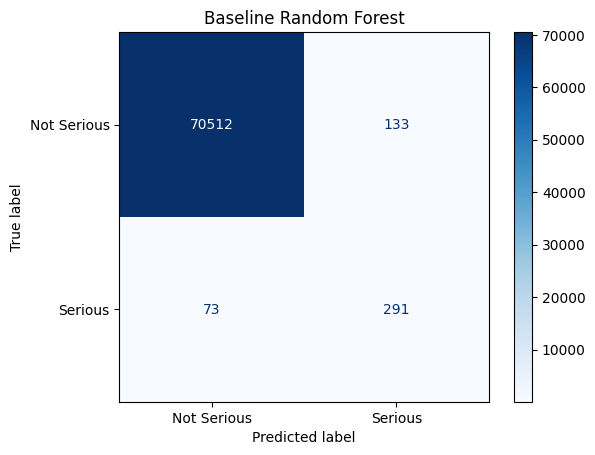

In [51]:
#confusion matrix for baseline model
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_seq,
    baseline_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Serious",
        "Serious"
    ]
)

disp.plot(cmap="Blues")

plt.title("Baseline Random Forest")
plt.show()

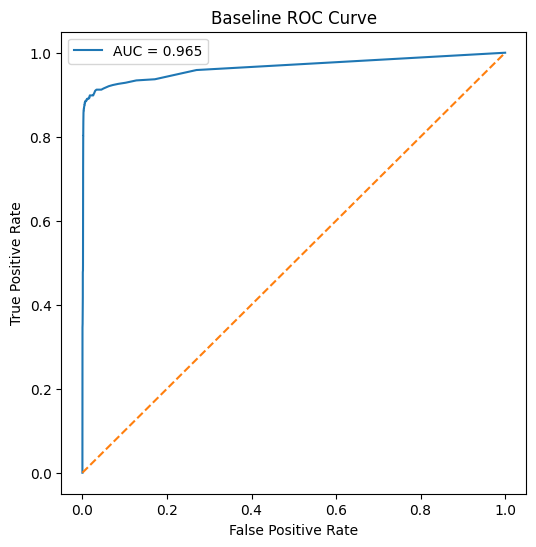

In [52]:
#RoC curve for baseline model
from sklearn.metrics import roc_curve

fpr,tpr,_ = roc_curve(
    y_test_seq,
    baseline_prob
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test_seq,baseline_prob):.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Baseline ROC Curve")

plt.legend()

plt.show()

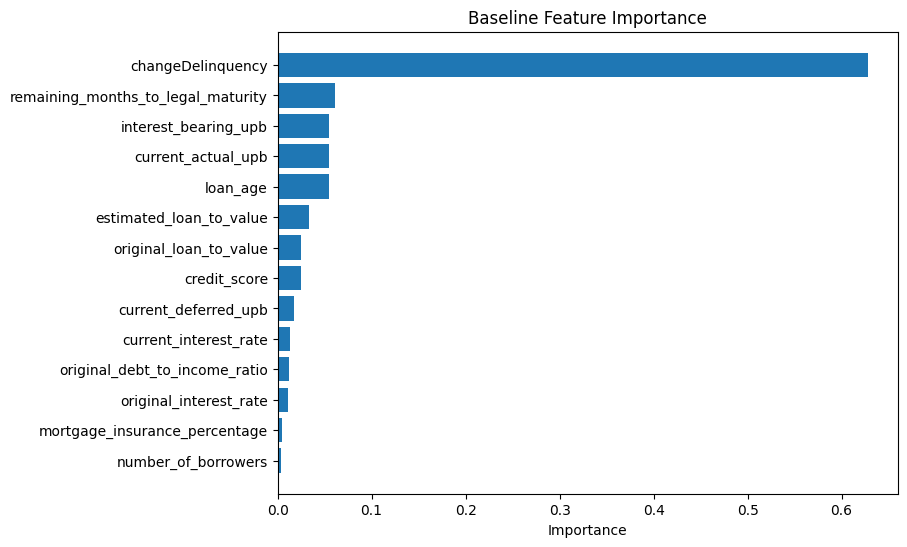

In [53]:
#feature importance for baseline model
feature_importance = pd.DataFrame({
    "Feature": sequential_features,
    "Importance": np.zeros(len(sequential_features))
})

importance = rf_baseline.feature_importances_

for i,feature in enumerate(sequential_features):

    feature_importance.loc[
        feature_importance.Feature==feature,
        "Importance"
    ] = importance[i::len(sequential_features)].sum()

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

#plot graph 
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance.Feature,
    feature_importance.Importance
)

plt.gca().invert_yaxis()

plt.title("Baseline Feature Importance")

plt.xlabel("Importance")

plt.show()

Threshold = 0.10

              precision    recall  f1-score   support

 Not Serious       1.00      0.99      0.99     70645
     Serious       0.25      0.89      0.39       364

    accuracy                           0.99     71009
   macro avg       0.62      0.94      0.69     71009
weighted avg       1.00      0.99      0.99     71009



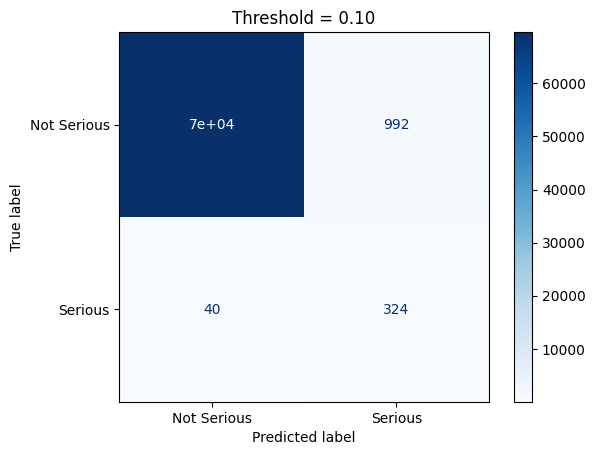

In [54]:
#Model 2 - Threshold Adjustment Random Forest

threshold = 0.10

threshold_pred = (
    baseline_prob >= threshold
).astype(int)

#metrics 
print("Threshold = 0.10\n")

print(classification_report(
    y_test_seq,
    threshold_pred,
    target_names=[
        "Not Serious",
        "Serious"
    ]
))

#confusion matrix for threshold adjustment model
cm = confusion_matrix(
    y_test_seq,
    threshold_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Serious",
        "Serious"
    ]
)

disp.plot(cmap="Blues")

plt.title("Threshold = 0.10")

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
#threshold adjustment model with threshold = 0.50

rf_probs = rf_baseline.predict_proba(X_test_seq)[:, 1]

thresholds = [0.50, 0.30, 0.20, 0.15, 0.10, 0.05]

results = []

for t in thresholds:

    preds = (rf_probs >= t).astype(int)

    precision = precision_score(y_test_seq, preds)
    recall = recall_score(y_test_seq, preds)
    f1 = f1_score(y_test_seq, preds)

    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1"]
)

print(results_df)

   Threshold  Precision    Recall        F1
0       0.50   0.681499  0.799451  0.735777
1       0.30   0.453901  0.879121  0.598690
2       0.20   0.396552  0.884615  0.547619
3       0.15   0.345494  0.884615  0.496914
4       0.10   0.246951  0.890110  0.386635
5       0.05   0.144235  0.903846  0.248771


Threshold = 0.50

              precision    recall  f1-score   support

 Not Serious       1.00      1.00      1.00     70645
     Serious       0.68      0.80      0.74       364

    accuracy                           1.00     71009
   macro avg       0.84      0.90      0.87     71009
weighted avg       1.00      1.00      1.00     71009



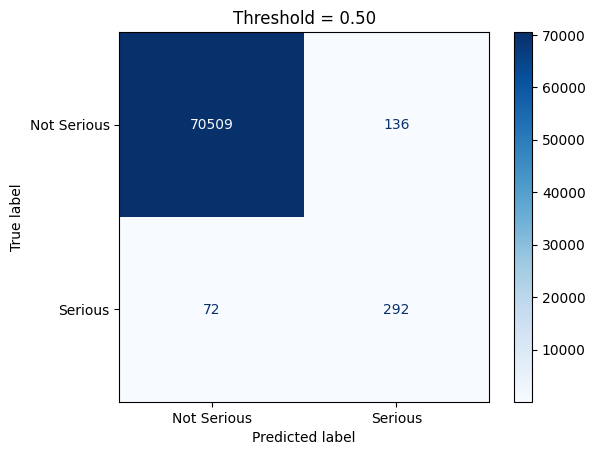

In [ ]:
#threshold adjustment model with threshold = 0.50
threshold = 0.50

threshold_pred = (
    baseline_prob >= threshold
).astype(int)

#metrics 
print("Threshold = 0.50\n")

print(classification_report(
    y_test_seq,
    threshold_pred,
    target_names=[
        "Not Serious",
        "Serious"
    ]
))

#confusion matrix for threshold adjustment model
cm = confusion_matrix(
    y_test_seq,
    threshold_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Serious",
        "Serious"
    ]
)

disp.plot(cmap="Blues")

plt.title("Threshold = 0.50")

plt.show()

In [55]:
#SMOTE Random Forest Model
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    k_neighbors=3
)

X_train_smote,y_train_smote = smote.fit_resample(
    X_train_seq_imputed,
    y_train_seq
)

#Train Random Forest on SMOTE data
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

#predict 
smote_prob = rf_smote.predict_proba(
    X_test_seq_imputed
)[:,1]

smote_pred = rf_smote.predict(
    X_test_seq_imputed
)

#metrics for SMOTE model
print("Random Forest + SMOTE\n")

print("Accuracy:", round(
    accuracy_score(y_test_seq,smote_pred),4))

print("Precision:", round(
    precision_score(y_test_seq,smote_pred),4))

print("Recall:", round(
    recall_score(y_test_seq,smote_pred),4))

print("F1:", round(
    f1_score(y_test_seq,smote_pred),4))

print("ROC-AUC:", round(
    roc_auc_score(y_test_seq,smote_prob),4))

print(classification_report(
    y_test_seq,
    smote_pred,
    target_names=[
        "Not Serious",
        "Serious"
    ]
))


/Users/gianellarobles/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Random Forest + SMOTE

Accuracy: 0.9981
Precision: 0.8135
Recall: 0.8269
F1: 0.8202
ROC-AUC: 0.9656
              precision    recall  f1-score   support

 Not Serious       1.00      1.00      1.00     70645
     Serious       0.81      0.83      0.82       364

    accuracy                           1.00     71009
   macro avg       0.91      0.91      0.91     71009
weighted avg       1.00      1.00      1.00     71009



In [62]:
#Model 4 - Random Forest SMOTE and Threshold Adjustment
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

smote_probs = rf_smote.predict_proba(X_test_seq)[:, 1]

thresholds = [0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05]

results = []

for threshold in thresholds:

    predictions = (smote_probs >= threshold).astype(int)

    precision = precision_score(y_test_seq, predictions)
    recall = recall_score(y_test_seq, predictions)
    f1 = f1_score(y_test_seq, predictions)

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

   Threshold  Precision    Recall        F1
0       0.50   0.809140  0.826923  0.817935
1       0.40   0.766990  0.868132  0.814433
2       0.30   0.657143  0.884615  0.754098
3       0.20   0.481315  0.884615  0.623427
4       0.15   0.303774  0.884615  0.452247
5       0.10   0.165901  0.892857  0.279811
6       0.05   0.066707  0.917582  0.124372


In [63]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Random Forest + Threshold (0.10)",
        "Random Forest + SMOTE"
    ],
    "Accuracy": [
        0.9971,
        0.9860,
        0.9982
    ],
    "Precision": [
        0.6815,
        0.2470,
        0.8091
    ],
    "Recall": [
        0.7995,
        0.8901,
        0.8269
    ],
    "F1 Score": [
        0.7358,
        0.3866,
        0.8179
    ],
    "ROC-AUC": [
        0.9654,
        0.9654,
        0.9656
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Random Forest,0.9971,0.6815,0.7995,0.7358,0.9654
1,Random Forest + Threshold (0.10),0.9860,0.2470,0.8901,0.3866,0.9654
2,Random Forest + SMOTE,0.9982,0.8091,0.8269,0.8179,0.9656
